#### Predict the price of the house using various housing features with the help of Support Vector Regressor


#### Step 1: Import all the necessary libraries

In [225]:
import      numpy                   as      np
import      pandas                  as      pd
import      matplotlib.pyplot       as      plt
import      seaborn                 as      sns
import      joblib

from        sklearn.model_selection     import  train_test_split
from        sklearn.preprocessing       import  StandardScaler
from        sklearn.svm                 import  SVR
from        sklearn.metrics             import  mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2: Load the Dataset

In [226]:
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

In [227]:
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


#### OBSERVATIONS:

1.  The above dataset explains about the features of the Boston Houses.

2.  There are total 506 records

3.  The independent or the input features used in the dataset is from crim ....... till lstat.

4.  The dependent feature is the medv(House Price). It is the output.

#### Step 3: Perform the Data Exploration

In [228]:
### Length of the dataset

print("Total length of the dataset is:", len(df))

Total length of the dataset is: 506


In [229]:
#### Shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (506, 14)


In [230]:
#### Get the columns used in the dataset

df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [231]:
#### Get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [232]:
#### Get the descriptive summary statistics about the dataset

df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [233]:
#### Get the correlation between all the numerical features used in the dataset

df.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


<Axes: >

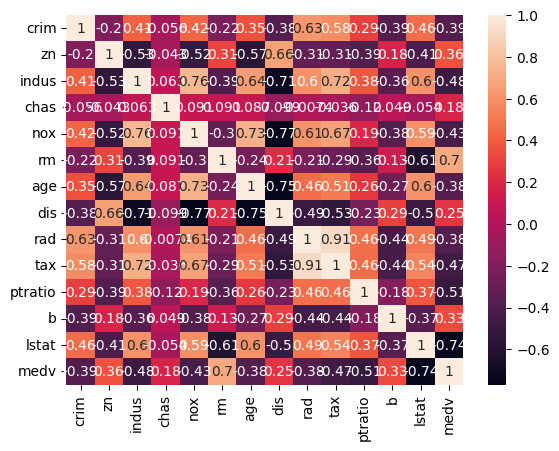

In [234]:
#### get the graphical representation between all the columns used in the dataset

sns.heatmap(df.corr(),annot=True)

#### OBSERVATIONS:

1.  The above graph shows about the visual representation between all the numerical columns used in the dataset.

2.  The high correlation represents red in color

    and the low correlation represents dark blue in color.

#### Step 4: Perform the Data Cleaning

In [235]:
#### Check whether there are any NULL Values in the dataset

print(df.isnull().sum())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [236]:
#### Check whether there are any duplicate records in the dataset

df[df.duplicated()]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Divide the dataset into the independent and dependent features

In [237]:
#### independent features

X = df.drop(columns='medv',axis=1)

print(X)

        crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     ptratio       b  lstat  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       17.8  392.83   4.03  
3  

In [238]:
#### dependent features

Y = df['medv']

print(Y)

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 506, dtype: float64


#### OBSERVATIONS:

1.  The above datset is divided into the independent and dependent features.

2.  The independent features is the input that comprises of crim ...till lstat.

3.  The dependent feature is the output that is the 'medv' or the house price.

#### Step 6: Divide the independent and dependent variables into the training and testing data

In [239]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [240]:
X_train

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666,20.2,349.48,24.91
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307,21.0,395.62,8.47
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304,16.9,362.25,7.83
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666,20.2,2.52,23.29
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307,21.0,390.95,11.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0,0.5200,5.836,91.9,2.2110,5,384,20.9,395.67,18.66
270,0.29916,20.0,6.96,0,0.4640,5.856,42.1,4.4290,3,223,18.6,388.65,13.00
348,0.01501,80.0,2.01,0,0.4350,6.635,29.7,8.3440,4,280,17.0,390.94,5.99
435,11.16040,0.0,18.10,0,0.7400,6.629,94.6,2.1247,24,666,20.2,109.85,23.27


In [241]:
X_test

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296,16.6,395.50,9.04
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254,17.6,396.90,3.53
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711,20.1,390.11,18.07
72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305,19.2,390.91,5.52
452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666,20.2,385.09,17.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,18.81100,0.0,18.10,0,0.597,4.628,100.0,1.5539,24,666,20.2,28.79,34.37
436,14.42080,0.0,18.10,0,0.740,6.461,93.3,2.0026,24,666,20.2,27.49,18.05
411,14.05070,0.0,18.10,0,0.597,6.657,100.0,1.5275,24,666,20.2,35.05,21.22
86,0.05188,0.0,4.49,0,0.449,6.015,45.1,4.4272,3,247,18.5,395.99,12.86


In [242]:
print("Shape of the input training data is:",X_train.shape)
print("Shape of the input testing  data is:",X_test.shape)

Shape of the input training data is: (404, 13)
Shape of the input testing  data is: (102, 13)


In [243]:
Y_train

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
       ... 
106    19.5
270    21.1
348    24.5
435    13.4
102    18.6
Name: medv, Length: 404, dtype: float64

In [244]:
Y_test

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
412    17.9
436     9.6
411    17.2
86     22.5
75     21.4
Name: medv, Length: 102, dtype: float64

In [245]:
print("Shape of the output training data is:",Y_train.shape)
print("Shape of the output testing  data is:",Y_test.shape)

Shape of the output training data is: (404,)
Shape of the output testing  data is: (102,)


#### OBSERVATIONS:

1.  The dataset is divided into the training and testing data.

2.  The training data contains 80 % of the data and the testing data contains 20 % of the data.

#### Step 7: Perform the Feature Scaling on the inputs

In [246]:
from sklearn.preprocessing import StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, scale the inputs in one range

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled  = sc.transform(X_test)

In [247]:
X_train_scaled

array([[ 1.28770177, -0.50032012,  1.03323679, ...,  0.84534281,
        -0.07433689,  1.75350503],
       [-0.33638447, -0.50032012, -0.41315956, ...,  1.20474139,
         0.4301838 , -0.5614742 ],
       [-0.40325332,  1.01327135, -0.71521823, ..., -0.63717631,
         0.06529747, -0.65159505],
       ...,
       [-0.40547014,  2.95931752, -1.30336132, ..., -0.59225149,
         0.37901005, -0.91069248],
       [ 0.85189733, -0.50032012,  1.03323679, ...,  0.84534281,
        -2.69458597,  1.52257036],
       [-0.38135592, -0.50032012, -0.35216694, ...,  1.15981657,
        -3.12158061, -0.25731635]], shape=(404, 13))

In [248]:
X_test_scaled

array([[-0.39680933, -0.50032012, -1.00711147, ..., -0.77195078,
         0.42887165, -0.48121032],
       [-0.40079621,  1.2294987 , -0.66439105, ..., -0.32270256,
         0.44418004, -1.25709448],
       [-0.39523443, -0.50032012,  2.43316256, ...,  0.80041799,
         0.36993437,  0.79033849],
       ...,
       [ 1.1779666 , -0.50032012,  1.03323679, ...,  0.84534281,
        -3.5124912 ,  1.23390203],
       [-0.40131065, -0.50032012, -0.94321444, ...,  0.08162084,
         0.43422959,  0.05669848],
       [-0.39643252, -0.50032012,  0.26792466, ...,  0.17147048,
         0.29470458, -0.49529171]], shape=(102, 13))

#### OBSERVATIONS:

1.  The entire inputs is now in the same scale range after applying standard scaler.

#### Step 8: Train the Support Vector Regressor

In [249]:
from    sklearn.svm     import SVR

#### Create an object for SVR

svr = SVR(
    kernel   =    'rbf'               ,
    C        =     100                ,
    gamma    =     0.1                ,
    epsilon  =     0.1
)


#### using the object for svr, train the model

svr.fit(X_train_scaled, Y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


#### OBSERVATIONS:

1. The Support Vector Regressor model is trained using the training data and with the help of the following parameters:---

   (a.)   kernel = 'Radial Basis Function'.  It works with the non-linear data.

   (b.)   C  =  100. It is the regularization strength that is used to prevent the overfitting.

   (c.)   gamma = 0.1. It explains how far does the influence of the single data point reaches.

   (d.)   epsilon = 0.1. It explains about the radius around the regression line.

#### Step 9: Predict the Model

In [250]:
Y_pred = svr.predict(X_test_scaled)

In [251]:
Y_pred

array([26.4257436 , 31.96935351, 14.76689538, 22.18065541, 16.09453   ,
       22.1891502 , 19.3246894 , 15.57662521, 21.80636858, 19.51783921,
       19.14029194, 18.80737189, 17.05454689, 23.29282927, 17.39016777,
       24.28933042, 19.8084806 , 10.83531193, 46.63353303, 13.36571711,
       23.5244275 , 26.09921499, 12.91122498, 25.100053  , 16.03400119,
       18.00345363, 21.19989408, 11.3376937 , 18.70945047, 19.15775535,
       24.04324592, 23.35545989, 24.03300737, 27.6101799 , 14.90110837,
       17.85828724, 32.34465542, 19.47936677, 22.40415737, 23.48852381,
       17.6561467 , 29.08056271, 48.83891578, 20.03312461, 24.37712021,
       15.39737894, 14.31497247, 24.27071579, 18.64317992, 25.49466372,
       20.45848501, 35.50838565, 16.92142497, 24.38309767, 46.77453911,
       22.59255424, 15.61515603, 32.73612875, 23.76932177, 17.21086774,
       25.89864722, 32.15928459, 30.07601101, 20.52695384, 23.56190521,
       18.58007141, 14.1139013 , 23.57705596, 27.7465225 , 17.09

#### Step 10: Compare the Actual vs Predicted Results and store the residual in the dataframe

In [252]:
res = pd.DataFrame({
    'Actual Results'    :    Y_test             ,
    'Predicted Resuts'  :    Y_pred             ,
    'Residuals'         :    (Y_test - Y_pred)  
})

In [253]:
res

,Actual Results,Predicted Resuts,Residuals
173,23.6,26.425744,-2.825744
274,32.4,31.969354,0.430646
491,13.6,14.766895,-1.166895
72,22.8,22.180655,0.619345
452,16.1,16.094530,0.005470
...,...,...,...
412,17.9,15.750606,2.149394
436,9.6,9.271874,0.328126
411,17.2,11.335265,5.864735
86,22.5,21.790700,0.709300


#### Step 11: Evaluate the Regression Metrics

In [254]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [255]:
mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error of the model is:", mae)

Mean Absolute Error of the model is: 2.171495740472565


In [256]:
mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared Error of the model is:", mse)

Mean Squared Error of the model is: 12.551945372890025


In [257]:
rmse = root_mean_squared_error(Y_test, Y_pred)

print("Root Mean Squared Error of the model is:", rmse)

Root Mean Squared Error of the model is: 3.542872474827456


In [258]:
r2 = r2_score(Y_test, Y_pred)

print("R2 Score of the model is:", r2)

R2 Score of the model is: 0.8288381584589894


#### OBSERVATIONS:

1.  The R2 Score of the model is 0.82 which is very high. So the model is working very fine.

#### Step 12: Save and Dump the Model

In [259]:
import joblib

joblib.dump(sc,"Standard_svr.pickle")

['Standard_svr.pickle']

In [260]:
joblib.dump(svr,"Support_Vector_Regressor.pickle")

['Support_Vector_Regressor.pickle']